# Modelado de la Curva de Crecimiento de Interacciones — v3

## Cambio respecto a v2: corrección del offset temporal

El scraping se realizó todos los días a las ~23h. Esto significa que:

- `dia_relativo = 0` **no** es "recién publicado" sino "medido la noche del mismo día de publicación".
- Una publicación hecha al mediodía ya lleva ~11h de vida en la primera medición.
- Una publicación hecha a las 22h lleva apenas ~1h.

Si usamos `t = dia_relativo` directamente, la Weibull asume que en `t=0` no hay interacciones, pero en la realidad ya hay muchas. Esto **subestima la velocidad de crecimiento temprano**.

### Solución: Weibull con offset `t0`

$$F(t) = 1 - e^{-k \cdot (t + t_0)^{\alpha}}$$

donde `t0 ∈ (0, 1]` es el offset temporal aprendido de los datos. Representa cuánto tiempo (en días) llevaba ya publicado el post en el momento de la **primera medición**. El modelo aprende este valor directamente de los datos — no hay que asumirlo.

Con este cambio:
- `F(0)` ya no es cero — refleja las interacciones acumuladas durante el primer día
- La curva arranca en el valor correcto sin necesidad de anclar artificialmente en cero
- `t0` tiene interpretación física directa: si resulta ~0.5, significa que las publicaciones se hacen en promedio a mediodía

## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import hashlib
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga y preparación de datos

Sin cambios respecto a v2, salvo que mantenemos `dia_relativo >= 0` (el día 0 es válido y necesario — es la primera medición real).

In [2]:
file_path = 'Scrapping data v2.xlsx'
xl = pd.ExcelFile(file_path)

df_fb = pd.read_excel(xl, sheet_name='Facebook')
df_ig = pd.read_excel(xl, sheet_name='Instagram')
df_tk = pd.read_excel(xl, sheet_name='TikTok')
df_tw = pd.read_excel(xl, sheet_name='Twitter')

def generate_id(text):
    if pd.isna(text): return 'missing_text'
    return hashlib.md5(str(text).encode('utf-8')).hexdigest()

if df_tw['postId'].isnull().all() or df_tw['postId'].astype(str).str.strip().eq('').all():
    df_tw['postId'] = df_tw['text'].apply(generate_id)

def prepare_evolution_df(df, platform, mapping, user_col, id_col, date_pub_col):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()

    actual_user_col = next(
        (col for col in [user_col, 'Username', 'name', 'Candidato'] if col in df.columns), None
    )
    df['candidate'] = df[actual_user_col].astype(str) if actual_user_col else 'Desconocido'
    df = df[~df['candidate'].str.contains('Desconocido|nan|None', case=False, na=True)]

    df['platform'] = platform
    df['internal_post_id'] = platform + '_' + df[id_col].astype(str)
    df = df.rename(columns=mapping)

    p_col = 'fecha_pub' if 'fecha_pub' in df.columns else (
        date_pub_col if date_pub_col in df.columns else None
    )
    df['fecha_ext'] = pd.to_datetime(df['fecha_ext'], errors='coerce', dayfirst=True).dt.tz_localize(None)
    df['fecha_pub'] = pd.to_datetime(df[p_col], errors='coerce', dayfirst=True).dt.tz_localize(None)
    df['dia_relativo'] = (df['fecha_ext'] - df['fecha_pub']).dt.days
    df = df[df['dia_relativo'] >= 0]  # día 0 = primera medición, es válido

    for col in ['likes', 'comments', 'shares']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        else:
            df[col] = 0.0

    return df[['internal_post_id', 'platform', 'candidate', 'fecha_pub',
               'dia_relativo', 'likes', 'comments', 'shares']]

ev_fb = prepare_evolution_df(df_fb, 'Facebook',
    {'megusta': 'likes', 'comentarios': 'comments', 'compartidas': 'shares'},
    'Username', 'postId', 'fecha_pub')
ev_ig = prepare_evolution_df(df_ig, 'Instagram',
    {'megusta': 'likes', 'comentarios': 'comments'},
    'Username', 'postId', 'fecha_pub')
ev_tk = prepare_evolution_df(df_tk, 'TikTok',
    {'megusta': 'likes', 'comentarios': 'comments', 'compartidos': 'shares'},
    'Username', 'postId', 'fecha_pub')
ev_tw = prepare_evolution_df(df_tw, 'Twitter',
    {'likecount': 'likes', 'replycount': 'comments', 'retweet_count': 'shares'},
    'Username', 'postId', 'createdat')

df_combined = pd.concat([ev_fb, ev_ig, ev_tk, ev_tw], ignore_index=True)
df_combined['total_int'] = df_combined['likes'] + df_combined['comments'] + df_combined['shares']

print(f'Publicaciones únicas: {df_combined["internal_post_id"].nunique():,}')
print(f'Observaciones totales: {len(df_combined):,}')
print(f'Plataformas: {df_combined["platform"].value_counts().to_dict()}')
print(f'Días relativos — min: {df_combined["dia_relativo"].min()}, max: {df_combined["dia_relativo"].max()}')

Publicaciones únicas: 2,026
Observaciones totales: 19,439
Plataformas: {'Facebook': 6750, 'Instagram': 5938, 'TikTok': 3943, 'Twitter': 2808}
Días relativos — min: 0, max: 18


## 2. Diagnóstico de cobertura del scraping

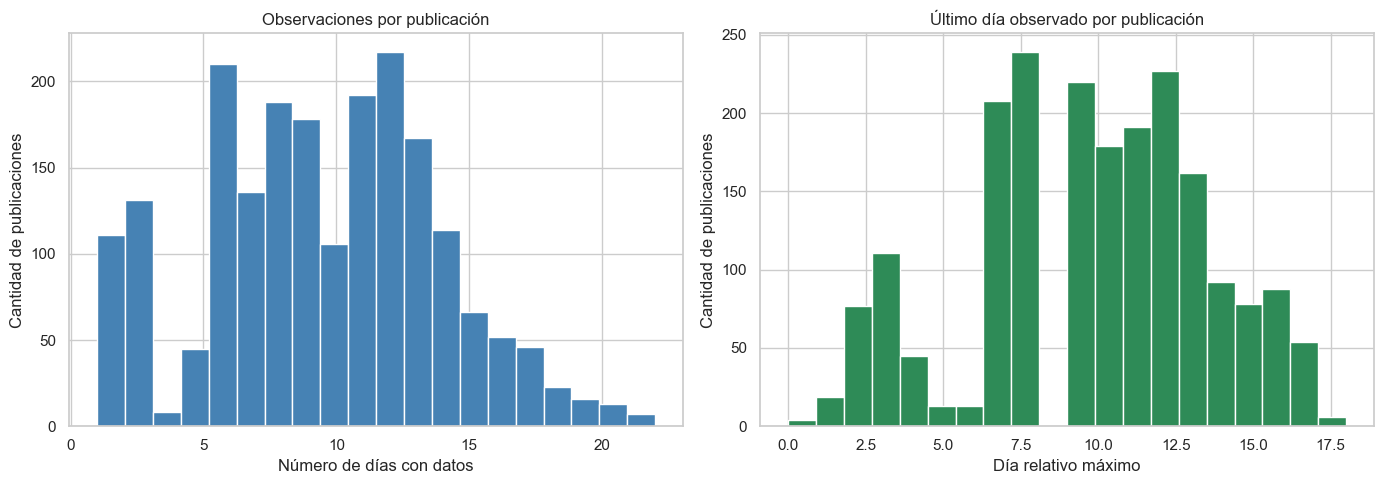

Publicaciones con solo 1 observación: 25
Publicaciones con 2+ observaciones:   2001
Mediana de observaciones por publicación: 10
Mediana del último día observado:         10


In [3]:
obs_per_post = df_combined.groupby('internal_post_id')['dia_relativo'].count()
max_day_per_post = df_combined.groupby('internal_post_id')['dia_relativo'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(obs_per_post, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Observaciones por publicación')
axes[0].set_xlabel('Número de días con datos')
axes[0].set_ylabel('Cantidad de publicaciones')

axes[1].hist(max_day_per_post, bins=20, color='seagreen', edgecolor='white')
axes[1].set_title('Último día observado por publicación')
axes[1].set_xlabel('Día relativo máximo')
axes[1].set_ylabel('Cantidad de publicaciones')

plt.tight_layout()
plt.show()

print(f'Publicaciones con solo 1 observación: {(obs_per_post == 1).sum()}')
print(f'Publicaciones con 2+ observaciones:   {(obs_per_post >= 2).sum()}')
print(f'Mediana de observaciones por publicación: {obs_per_post.median():.0f}')
print(f'Mediana del último día observado:         {max_day_per_post.median():.0f}')

## 3. Construcción del panel de fracciones

Igual que v2: normalizamos cada publicación por su valor más tardío observado, sin interpolar huecos.

**Diferencia clave:** ahora el día 0 **se incluye** en el panel y en el ajuste — es la primera medición real y tiene valor informativo sobre cuánto creció el post en sus primeras horas.

In [4]:
MIN_OBSERVACIONES = 2
MIN_DIA_MAX = 3

def build_fraction_panel(group):
    group = group.sort_values('dia_relativo').drop_duplicates('dia_relativo')

    if len(group) < MIN_OBSERVACIONES:
        return None
    if group['dia_relativo'].max() < MIN_DIA_MAX:
        return None

    group = group.copy()
    group['total_int'] = group['total_int'].cummax()

    total_max = group.loc[group['dia_relativo'].idxmax(), 'total_int']
    if total_max <= 0:
        return None

    group['fraccion'] = (group['total_int'] / total_max).clip(0, 1)

    return group[['internal_post_id', 'platform', 'candidate',
                  'fecha_pub', 'dia_relativo', 'total_int', 'fraccion']]

panel_list = [
    build_fraction_panel(g)
    for _, g in df_combined.groupby('internal_post_id')
]
df_panel = pd.concat([p for p in panel_list if p is not None], ignore_index=True)

print(f'Publicaciones en el panel: {df_panel["internal_post_id"].nunique():,}')
print(f'Pares (día, fracción) disponibles: {len(df_panel):,}')
print(f'Incluye día 0: {(df_panel["dia_relativo"] == 0).sum():,} observaciones')
print()
print('Por plataforma:')
print(df_panel.groupby('platform')['internal_post_id'].nunique())

Publicaciones en el panel: 1,922
Pares (día, fracción) disponibles: 14,596
Incluye día 0: 370 observaciones

Por plataforma:
platform
Facebook     765
Instagram    603
TikTok       344
Twitter      210
Name: internal_post_id, dtype: int64


## 4. ¿Cuánto vale el offset? — análisis del día 0

Antes de ajustar el modelo, inspeccionamos empíricamente la distribución de fracciones en el día 0. Esto nos da una idea del offset `t0` que el modelo necesita aprender: si la mediana del día 0 es ~0.60, significa que al momento de la primera medición ya se había acumulado el 60% de las interacciones, lo que implica un crecimiento muy rápido en las primeras horas.

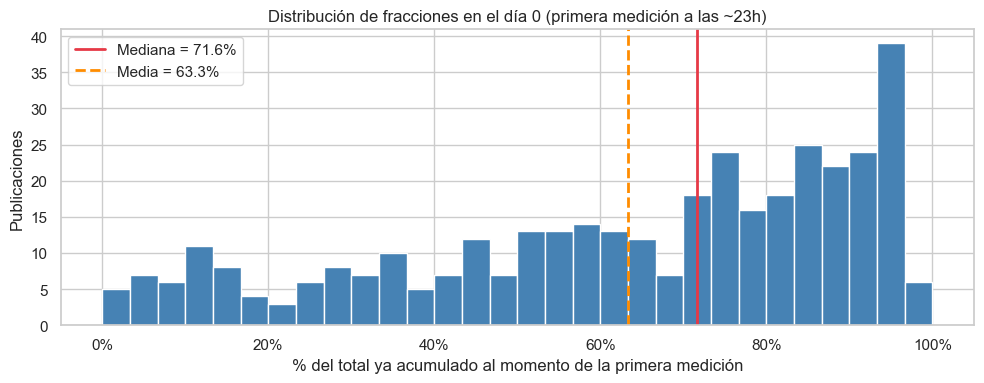

Mediana día 0: 71.6%
P25 día 0:     44.7%
P75 día 0:     86.2%

Interpretación: si la mediana es alta (>50%), las interacciones
se concentran fuertemente en las primeras horas.


In [5]:
dia0 = df_panel[df_panel['dia_relativo'] == 0]['fraccion']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dia0, bins=30, color='steelblue', edgecolor='white')
ax.axvline(dia0.median(), color='#E63946', linewidth=2,
           label=f'Mediana = {dia0.median():.1%}')
ax.axvline(dia0.mean(), color='darkorange', linewidth=2, linestyle='--',
           label=f'Media = {dia0.mean():.1%}')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Distribución de fracciones en el día 0 (primera medición a las ~23h)')
ax.set_xlabel('% del total ya acumulado al momento de la primera medición')
ax.set_ylabel('Publicaciones')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mediana día 0: {dia0.median():.1%}')
print(f'P25 día 0:     {dia0.quantile(0.25):.1%}')
print(f'P75 día 0:     {dia0.quantile(0.75):.1%}')
print()
print('Interpretación: si la mediana es alta (>50%), las interacciones')
print('se concentran fuertemente en las primeras horas.')

## 5. Visualización exploratoria del panel

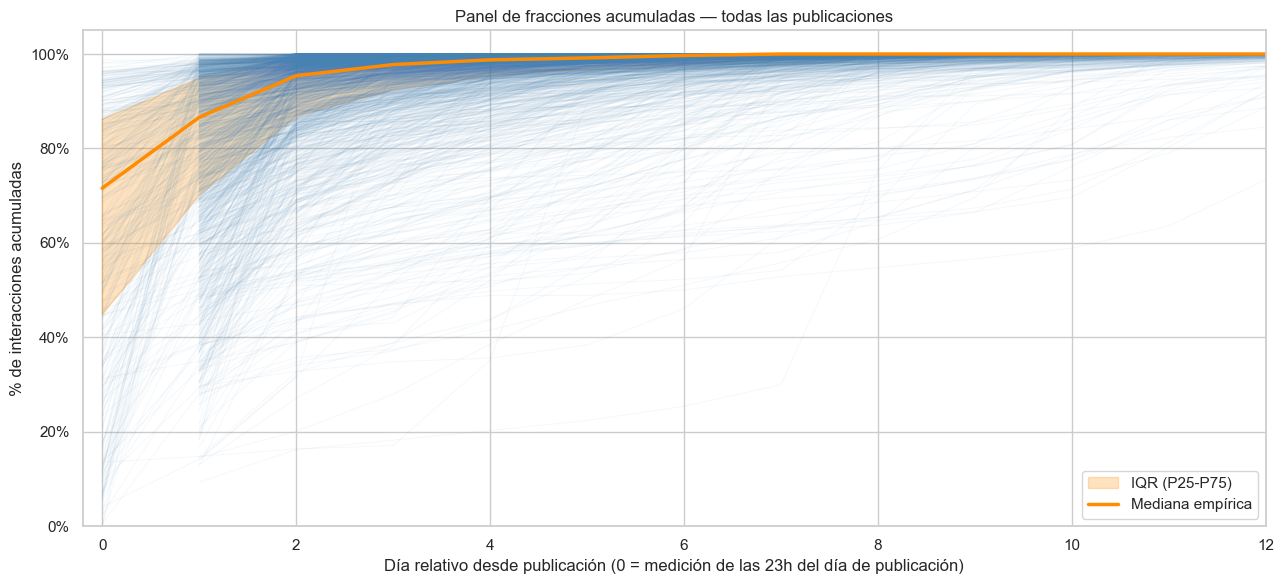

In [6]:
fig, ax = plt.subplots(figsize=(13, 6))

for post_id, group in df_panel.groupby('internal_post_id'):
    group = group.sort_values('dia_relativo')
    ax.plot(group['dia_relativo'], group['fraccion'],
            alpha=0.05, color='steelblue', linewidth=0.8)

median_curve = df_panel.groupby('dia_relativo')['fraccion'].median().reset_index()
q25 = df_panel.groupby('dia_relativo')['fraccion'].quantile(0.25).reset_index()
q75 = df_panel.groupby('dia_relativo')['fraccion'].quantile(0.75).reset_index()

ax.fill_between(q25['dia_relativo'], q25['fraccion'], q75['fraccion'],
                alpha=0.25, color='darkorange', label='IQR (P25-P75)')
ax.plot(median_curve['dia_relativo'], median_curve['fraccion'],
        color='darkorange', linewidth=2.5, label='Mediana empírica')

ax.set_xlim(-0.2, df_panel['dia_relativo'].quantile(0.95))
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Panel de fracciones acumuladas — todas las publicaciones')
ax.set_xlabel('Día relativo desde publicación (0 = medición de las 23h del día de publicación)')
ax.set_ylabel('% de interacciones acumuladas')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Ajuste del modelo Weibull con offset `t0`

Ajustamos tres variantes para comparar:

1. **Weibull sin offset** (v2): `F(t) = 1 - exp(-k·t^α)` — referencia
2. **Weibull con offset fijo** `t0=0.5`: asume publicación promedio al mediodía
3. **Weibull con offset libre**: `F(t) = 1 - exp(-k·(t+t0)^α)` — `t0` se aprende de los datos

La variante 3 es la correcta. Las otras dos sirven para ver el impacto del offset.

In [7]:
# Usamos TODOS los días, incluido el día 0
x_all = df_panel['dia_relativo'].values.astype(float)
y_all = df_panel['fraccion'].values.astype(float)

print(f'Pares usados para el ajuste: {len(x_all):,}')
print(f'Incluye {(x_all == 0).sum():,} observaciones del día 0')
print()

# --- Modelos ---

def weibull_sin_offset(t, k, alpha):
    """v2: F(t) = 1 - exp(-k * t^alpha). Problema: F(0)=0 no refleja la realidad."""
    t = np.maximum(t, 1e-9)
    return 1 - np.exp(-k * np.power(t, alpha))

def weibull_offset_fijo(t, k, alpha, t0=0.5):
    """Offset fijo de medio día (asume publicación al mediodía)."""
    return 1 - np.exp(-k * np.power(t + t0, alpha))

def weibull_offset_libre(t, k, alpha, t0):
    """Offset aprendido de los datos. t0 ∈ (0,1] representa las horas ya
    transcurridas al momento de la primera medición, expresadas en días."""
    return 1 - np.exp(-k * np.power(t + t0, alpha))

modelos = [
    ('Weibull sin offset (v2)',   weibull_sin_offset,   [[0.5, 0.5], [0.1, 0.8]],           (0, np.inf)),
    ('Weibull offset fijo 0.5',  lambda t,k,a: weibull_offset_fijo(t,k,a,0.5),
                                                         [[0.5, 0.5], [0.1, 0.8]],           (0, np.inf)),
    ('Weibull offset libre',     weibull_offset_libre, [[0.5, 0.5, 0.5], [0.1, 0.8, 0.3]],
                                                        ([0, 0, 0], [np.inf, np.inf, 1.0])),
]

results = {}

for name, func, p0_list, bounds in modelos:
    best_r2, best_popt, best_pred = -np.inf, None, None
    for p0 in p0_list:
        try:
            popt, _ = curve_fit(func, x_all, y_all, p0=p0,
                                maxfev=50000, bounds=bounds)
            y_pred = func(x_all, *popt)
            r2 = r2_score(y_all, y_pred)
            if r2 > best_r2:
                best_r2, best_popt, best_pred = r2, popt, y_pred
        except Exception:
            continue

    if best_popt is not None:
        rmse = np.sqrt(mean_squared_error(y_all, best_pred))
        results[name] = {'func': func, 'params': best_popt, 'r2': best_r2, 'rmse': rmse}
        params_str = ', '.join([f'{p:.4f}' for p in best_popt])
        print(f'{name:30s} | R²: {best_r2:.4f} | RMSE: {rmse:.4f} | Params: [{params_str}]')
    else:
        print(f'{name:30s} | No convergió')

print()
if 'Weibull offset libre' in results:
    p = results['Weibull offset libre']['params']
    horas = p[2] * 24
    print(f'→ t0 aprendido: {p[2]:.3f} días = {horas:.1f} horas')
    print(f'  Esto sugiere que en promedio las publicaciones se hacen ~{horas:.0f}h antes de la medición nocturna.')

# Mejor modelo = Weibull offset libre
best_name   = 'Weibull offset libre'
best_func   = weibull_offset_libre
best_params = results[best_name]['params']

Pares usados para el ajuste: 14,596
Incluye 370 observaciones del día 0

Weibull sin offset (v2)        | R²: 0.1770 | RMSE: 0.1185 | Params: [2.6455, 0.0508]
Weibull offset fijo 0.5        | R²: 0.3287 | RMSE: 0.1070 | Params: [1.3660, 0.5243]
Weibull offset libre           | R²: 0.3295 | RMSE: 0.1070 | Params: [1.1976, 0.6008, 0.7223]

→ t0 aprendido: 0.722 días = 17.3 horas
  Esto sugiere que en promedio las publicaciones se hacen ~17h antes de la medición nocturna.


## 7. Comparación visual de los tres modelos

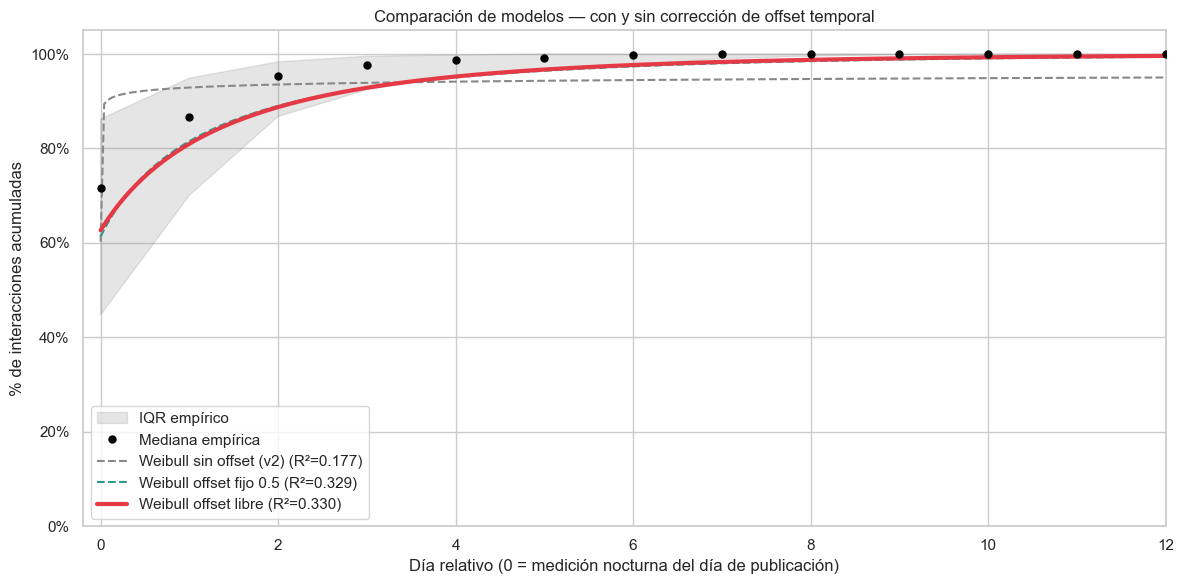

Mejora del offset libre respecto al modelo sin offset:
  R² sin offset:    0.1770
  R² offset libre:  0.3295
  Δ R²:             +0.1525


In [8]:
t_plot = np.linspace(0, df_panel['dia_relativo'].quantile(0.95), 300)

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(q25['dia_relativo'], q25['fraccion'], q75['fraccion'],
                alpha=0.2, color='gray', label='IQR empírico')
ax.plot(median_curve['dia_relativo'], median_curve['fraccion'],
        'o', color='black', markersize=5, label='Mediana empírica', zorder=5)

estilos = [
    ('Weibull sin offset (v2)',  '#888888', '--', 1.5),
    ('Weibull offset fijo 0.5', '#2A9D8F', '--', 1.5),
    ('Weibull offset libre',    '#E63946', '-',  3.0),
]

for name, color, ls, lw in estilos:
    if name not in results:
        continue
    res = results[name]
    y_curve = np.clip(res['func'](t_plot, *res['params']), 0, 1)
    ax.plot(t_plot, y_curve, color=color, linewidth=lw, linestyle=ls,
            label=f'{name} (R²={res["r2"]:.3f})')

ax.set_xlim(-0.2, t_plot.max())
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Comparación de modelos — con y sin corrección de offset temporal')
ax.set_xlabel('Día relativo (0 = medición nocturna del día de publicación)')
ax.set_ylabel('% de interacciones acumuladas')
ax.legend()
plt.tight_layout()
plt.show()

print('Mejora del offset libre respecto al modelo sin offset:')
r2_base = results.get('Weibull sin offset (v2)', {}).get('r2', None)
r2_best = results['Weibull offset libre']['r2']
if r2_base:
    print(f'  R² sin offset:    {r2_base:.4f}')
    print(f'  R² offset libre:  {r2_best:.4f}')
    print(f'  Δ R²:             +{r2_best - r2_base:.4f}')

## 8. Análisis de residuos

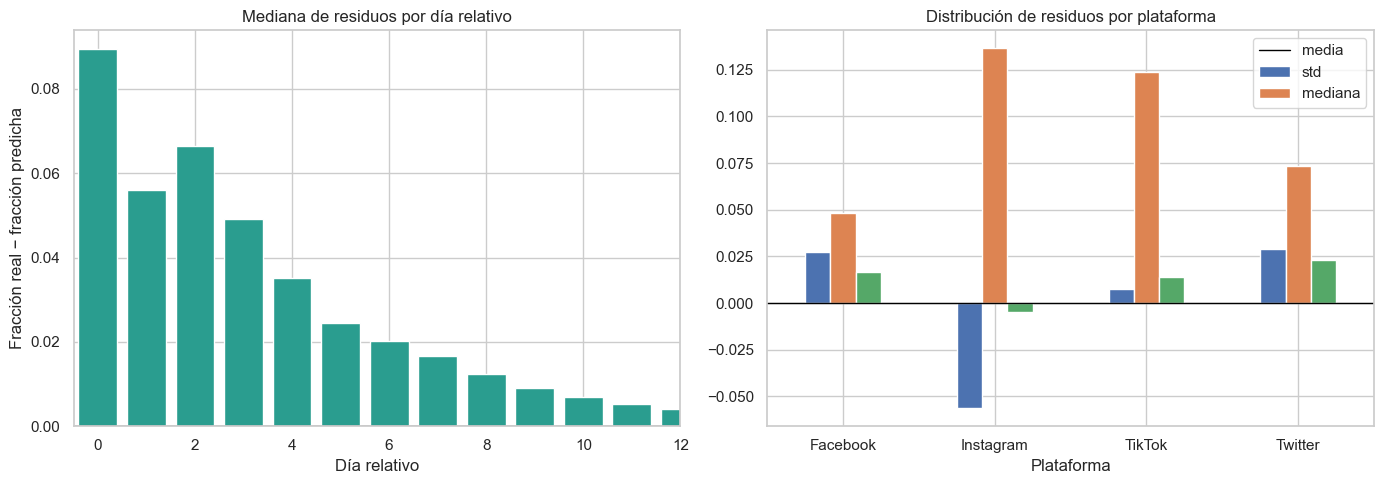

Sesgo por plataforma (media de residuos):
platform
Facebook     0.0273
Instagram   -0.0563
TikTok       0.0073
Twitter      0.0289
Name: residuo, dtype: float64


In [9]:
df_panel_resid = df_panel.copy()
df_panel_resid['y_pred'] = best_func(
    df_panel_resid['dia_relativo'].values.astype(float), *best_params
)
df_panel_resid['residuo'] = df_panel_resid['fraccion'] - df_panel_resid['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_by_day = df_panel_resid.groupby('dia_relativo')['residuo'].median()
axes[0].bar(res_by_day.index, res_by_day.values,
            color=['#E63946' if v < 0 else '#2A9D8F' for v in res_by_day.values],
            width=0.8)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlim(-0.5, df_panel['dia_relativo'].quantile(0.95))
axes[0].set_title('Mediana de residuos por día relativo')
axes[0].set_xlabel('Día relativo')
axes[0].set_ylabel('Fracción real − fracción predicha')

res_by_platform = df_panel_resid.groupby('platform')['residuo'].describe()[['mean', 'std', '50%']]
res_by_platform.plot(kind='bar', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Distribución de residuos por plataforma')
axes[1].set_xlabel('Plataforma')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['media', 'std', 'mediana'])

plt.tight_layout()
plt.show()

print('Sesgo por plataforma (media de residuos):')
print(df_panel_resid.groupby('platform')['residuo'].mean().round(4))

## 9. (Opcional) Modelos por plataforma con offset libre

Facebook     | k=1.4808, α=0.6295, t0=1.0000 (24.0h) | R²=0.3509
Instagram    | k=1.1369, α=0.5210, t0=0.0408 (1.0h) | R²=0.4026
TikTok       | k=1.3272, α=0.5124, t0=0.7886 (18.9h) | R²=0.3509
Twitter      | k=1.4454, α=1.1422, t0=0.2566 (6.2h) | R²=0.6905


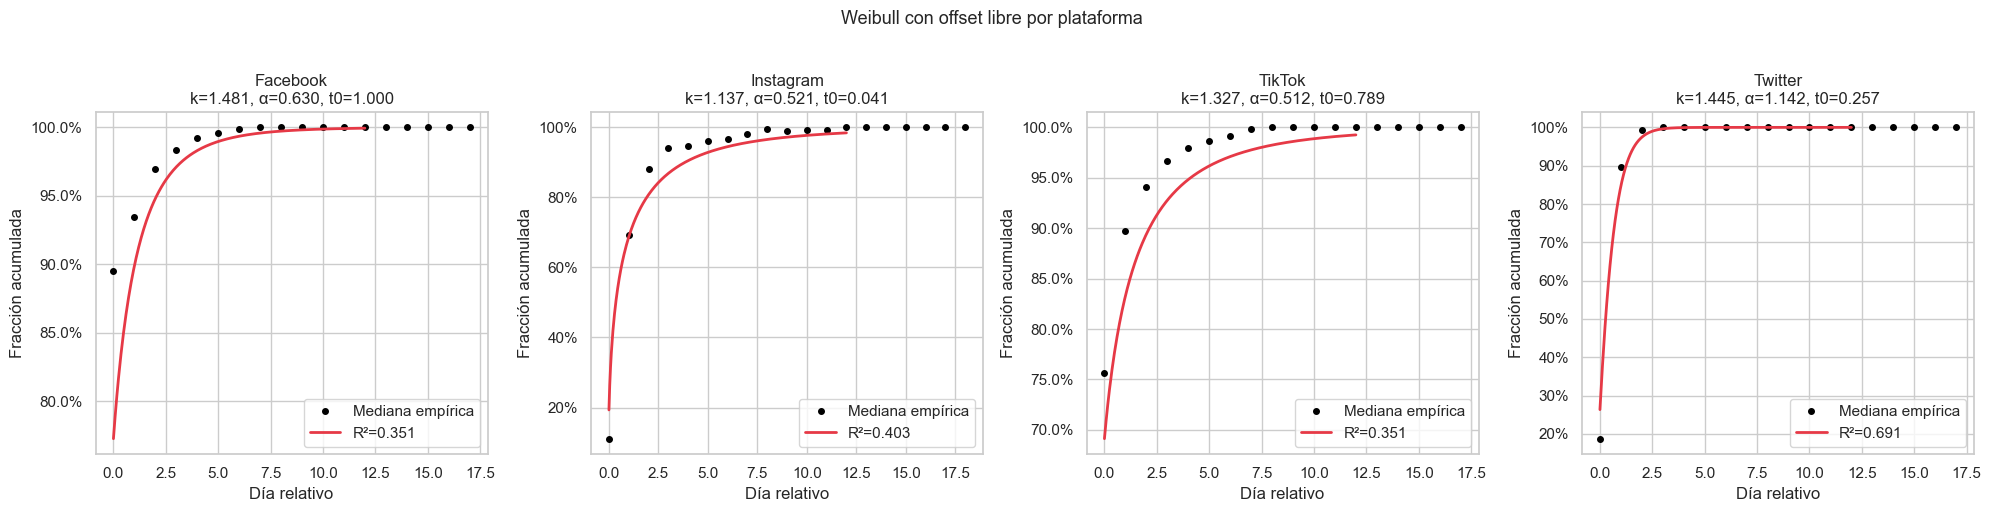

In [10]:
platform_models = {}

t_plot_p = np.linspace(0, df_panel['dia_relativo'].quantile(0.95), 300)
plats = df_panel['platform'].unique()
n_plats = len(plats)
fig, axes = plt.subplots(1, n_plats, figsize=(5 * n_plats, 5))
if n_plats == 1:
    axes = [axes]

for i, platform in enumerate(plats):
    sub = df_panel[df_panel['platform'] == platform]
    if len(sub) < 10:
        print(f'{platform}: datos insuficientes')
        continue

    x_p = sub['dia_relativo'].values.astype(float)
    y_p = sub['fraccion'].values.astype(float)

    best_r2_p, best_popt_p = -np.inf, None
    for p0 in [[0.5, 0.5, 0.5], [0.1, 0.8, 0.3], [1.0, 0.4, 0.6]]:
        try:
            popt, _ = curve_fit(
                weibull_offset_libre, x_p, y_p, p0=p0,
                maxfev=50000, bounds=([0, 0, 0], [np.inf, np.inf, 1.0])
            )
            r2 = r2_score(y_p, weibull_offset_libre(x_p, *popt))
            if r2 > best_r2_p:
                best_r2_p, best_popt_p = r2, popt
        except Exception:
            continue

    if best_popt_p is not None:
        k, alpha, t0 = best_popt_p
        platform_models[platform] = {'params': best_popt_p, 'r2': best_r2_p}

        med_p = sub.groupby('dia_relativo')['fraccion'].median()
        axes[i].plot(med_p.index, med_p.values, 'o', color='black',
                     markersize=4, label='Mediana empírica')
        y_curve = np.clip(weibull_offset_libre(t_plot_p, *best_popt_p), 0, 1)
        axes[i].plot(t_plot_p, y_curve, color='#E63946', linewidth=2,
                     label=f'R²={best_r2_p:.3f}')
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        axes[i].set_title(f'{platform}\nk={k:.3f}, α={alpha:.3f}, t0={t0:.3f}')
        axes[i].set_xlabel('Día relativo')
        axes[i].set_ylabel('Fracción acumulada')
        axes[i].legend()
        print(f'{platform:12s} | k={k:.4f}, α={alpha:.4f}, t0={t0:.4f} ({t0*24:.1f}h) | R²={best_r2_p:.4f}')

plt.suptitle('Weibull con offset libre por plataforma', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Función de reconstrucción histórica

Igual que v2 pero usando el modelo con offset. La función de reconstrucción ahora produce valores correctos en el día 0 — ya no empieza en cero sino en el valor que predice el modelo para las primeras horas de vida del post.

In [11]:
def reconstruir_curva(
    fecha_pub,
    total_interacciones,
    fecha_observacion=None,
    platform=None,
    dias_reconstruir=20,
    global_func=best_func,
    global_params=best_params,
    platform_models=platform_models
):
    """
    Reconstruye la curva histórica de interacciones de una publicación.

    Parámetros
    ----------
    fecha_pub : str o datetime
        Fecha de publicación del post.
    total_interacciones : int o float
        Interacciones conocidas. Si se provee fecha_observacion, se interpreta
        como medición parcial y se escala al total final estimado.
        Si no, se trata como total final ya estabilizado.
    fecha_observacion : str o datetime, opcional
        Fecha en que se midió total_interacciones.
    platform : str, opcional
        'Facebook', 'Instagram', 'TikTok', 'Twitter'.
        Si existe modelo por plataforma, lo usa.
    dias_reconstruir : int
        Días a reconstruir desde fecha_pub.

    Retorna
    -------
    pd.DataFrame con la curva reconstruida día a día.
    """
    fecha_pub = pd.to_datetime(fecha_pub)

    # Seleccionar modelo
    func = global_func
    params = global_params
    if platform and platform in platform_models:
        func = weibull_offset_libre
        params = platform_models[platform]['params']

    # Estimar total final
    if fecha_observacion is not None:
        fecha_obs = pd.to_datetime(fecha_observacion)
        dia_obs = max(0, (fecha_obs - fecha_pub).days)
        fraccion_en_obs = np.clip(func(float(dia_obs), *params), 0.01, 1.0)
        total_final = total_interacciones / fraccion_en_obs
        print(f'Día de observación: {dia_obs} | '
              f'Fracción estimada: {fraccion_en_obs:.1%} | '
              f'Total final estimado: {total_final:,.0f}')
    else:
        total_final = total_interacciones
        print(f'Total final (dado directamente): {total_final:,.0f}')

    # Construir curva día a día (incluye día 0)
    dias = np.arange(0, dias_reconstruir + 1)
    fraccion = np.clip(func(dias.astype(float), *params), 0, 1)

    # Normalizar para que el último día = 100%
    f_max = func(float(dias_reconstruir), *params)
    if f_max > 0:
        fraccion = fraccion / f_max
        fraccion = np.clip(fraccion, 0, 1)

    interacciones_cum = np.round(fraccion * total_final).astype(int)
    interacciones_nuevas = np.diff(interacciones_cum, prepend=0)
    fechas = [fecha_pub + pd.Timedelta(days=int(d)) for d in dias]

    return pd.DataFrame({
        'Fecha': fechas,
        'Día Relativo': dias,
        '% Acumulado': fraccion,
        'Interacciones Estimadas': interacciones_cum,
        'Interacciones Nuevas (ese día)': interacciones_nuevas
    })

## 11. Ejemplos de uso

In [12]:
# --- Ejemplo A: total final conocido ---
print('=== Ejemplo A: total final conocido ===')
curva_a = reconstruir_curva(
    fecha_pub='2026-01-15',
    total_interacciones=50_000,
    dias_reconstruir=20
)
print(curva_a.to_string(index=False))

=== Ejemplo A: total final conocido ===
Total final (dado directamente): 50,000
     Fecha  Día Relativo  % Acumulado  Interacciones Estimadas  Interacciones Nuevas (ese día)
2026-01-15             0     0.626943                    31347                           31347
2026-01-16             1     0.810393                    40520                            9173
2026-01-17             2     0.888154                    44408                            3888
2026-01-18             3     0.929049                    46452                            2044
2026-01-19             4     0.952899                    47645                            1193
2026-01-20             5     0.967728                    48386                             741
2026-01-21             6     0.977370                    48868                             482
2026-01-22             7     0.983851                    49193                             325
2026-01-23             8     0.988323                    49416   

In [13]:
# --- Ejemplo B: medición parcial en un día específico ---
print('=== Ejemplo B: medición parcial + fecha de observación ===')
curva_b = reconstruir_curva(
    fecha_pub='2026-01-15',
    total_interacciones=43_000,
    fecha_observacion='2026-01-25',
    platform='Instagram',
    dias_reconstruir=20
)
print(curva_b.to_string(index=False))

=== Ejemplo B: medición parcial + fecha de observación ===
Día de observación: 10 | Fracción estimada: 97.7% | Total final estimado: 44,003
     Fecha  Día Relativo  % Acumulado  Interacciones Estimadas  Interacciones Nuevas (ese día)
2026-01-15             0     0.194075                     8540                            8540
2026-01-16             1     0.689815                    30354                           21814
2026-01-17             2     0.811262                    35698                            5344
2026-01-18             3     0.872422                    38390                            2692
2026-01-19             4     0.908957                    39997                            1607
2026-01-20             5     0.932803                    41047                            1050
2026-01-21             6     0.949264                    41771                             724
2026-01-22             7     0.961084                    42291                             520
2026-

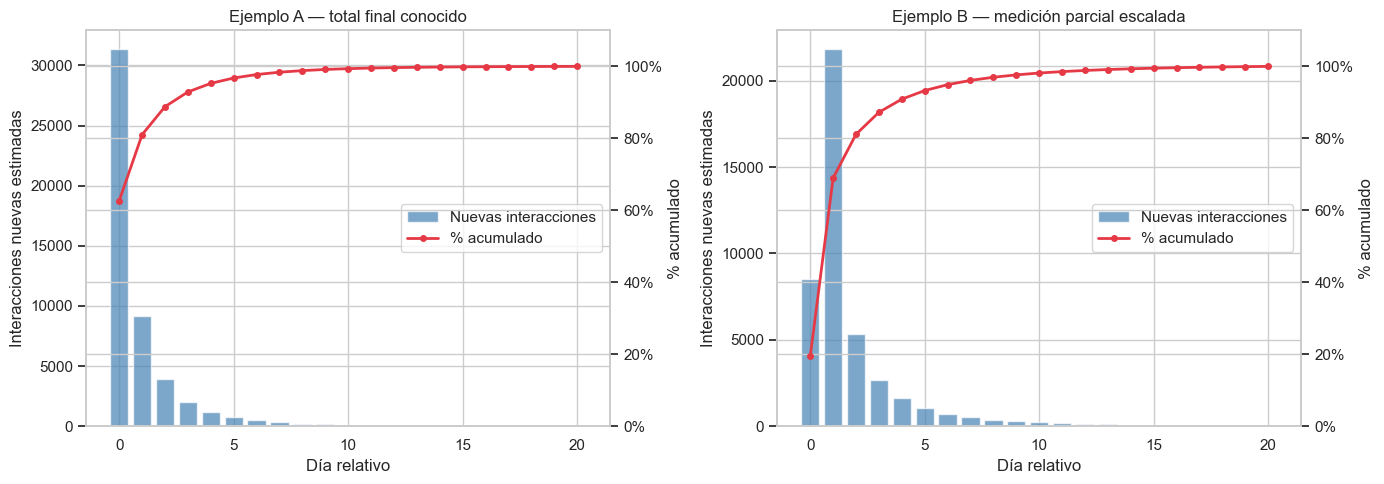

In [14]:
# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (curva, titulo) in zip(axes, [
    (curva_a, 'Ejemplo A — total final conocido'),
    (curva_b, 'Ejemplo B — medición parcial escalada')
]):
    ax.bar(curva['Día Relativo'], curva['Interacciones Nuevas (ese día)'],
           color='steelblue', alpha=0.7, label='Nuevas interacciones')
    ax2 = ax.twinx()
    ax2.plot(curva['Día Relativo'], curva['% Acumulado'],
             color='#E63946', linewidth=2, marker='o', markersize=4,
             label='% acumulado')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax2.set_ylim(0, 1.1)
    ax.set_title(titulo)
    ax.set_xlabel('Día relativo')
    ax.set_ylabel('Interacciones nuevas estimadas')
    ax2.set_ylabel('% acumulado')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()